В данной работе проводится обработка результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [66]:
model_name = "BISO"

nu_path = r"nu.txt"
with open(nu_path, "r") as f:
        nu = float(f.read().strip())
nu

0.299999999999

In [67]:
a_path = r"a.txt"
with open(a_path, "r") as f:
        a = float(f.read().strip())

c_path = r"c.txt"
with open(c_path, "r") as f:
        c = float(f.read().strip())

n_turns_path = r"n_turns.txt"
with open(n_turns_path, "r") as f:
        n_turns = float(f.read().strip())

a, c, n_turns

(0.0157, 0.0025, 2.0)

In [68]:
from core.reader import read_ansys_csv

numerical_experiment_data_biso = r"biso.csv"
numerical_experiment_biso = read_ansys_csv(numerical_experiment_data_biso)

### 1. Первичный обзор данных
Проверим структуру загруженного DataFrame. Данные содержат временные метки, компоненты тензоров деформаций (упругих `EPEL`, пластических `EPPL`, полных `EPTO`), напряжений (`S`), а также интенсивность деформаций и параметр Одквиста.

In [69]:
numerical_experiment_biso.sample(3, random_state=42)

,Time,EPEL_TT,EPPL_TT,EPTO_TT,EPEL_ZZ,EPPL_ZZ,EPTO_ZZ,EPEL_TZ,EPPL_TZ,EPTO_TZ,EPEL_RR,EPPL_RR,EPTO_RR,S_TT,S_ZZ,S_TZ,S_EQV,EPPL_EQV,NL_EPEQ
3207,213.7178,0.002132,0.002034,0.004166,-0.000456,0.005810,0.005353,0.001270,0.003017,0.004287,-0.000718,-0.007844,-0.008562,449.3497,41.24342,100.1230,463.8505,0.008325,0.009878
5890,392.5178,0.001959,0.008321,0.010280,0.000215,0.002633,0.002848,-0.002637,0.000432,-0.002205,-0.000932,-0.010954,-0.011886,455.9304,180.87080,-207.9308,536.4960,0.011439,0.016789
8814,587.4178,0.001890,0.011380,0.013270,0.001920,0.005549,0.007469,0.001776,-0.002458,-0.000682,-0.001633,-0.016929,-0.018562,555.4623,560.26590,140.0383,608.3271,0.017319,0.023621


### 2. Графики полных деформаций
Построим графики изменения компонент тензора полных деформаций от времени.
* `EPTO_ZZ` — осевая деформация ($\varepsilon_z$).
* `EPTO_TT` — окружная деформация ($\varepsilon_\theta$).
* `EPTO_TZ` — деформация сдвига ($\varepsilon_{\theta z}$).

На первом этапе (растяжение) должна меняться только $\varepsilon_z$. На втором этапе (винт) должны меняться все компоненты.

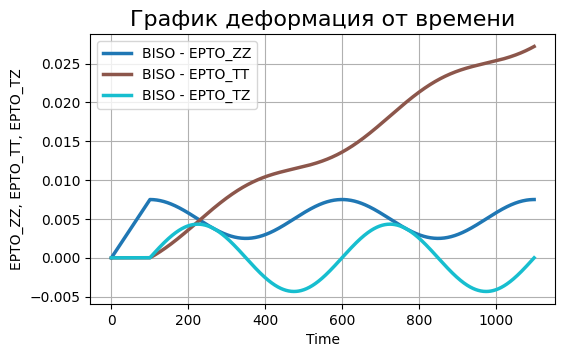

In [70]:
from core.visualizer import plot_xy

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"График деформация от времени"
)


### 3. Расчет вектора деформаций Ильюшина
Для анализа сложных процессов деформирования перейдем от тензорного представления к векторному в пятимерном евклидовом пространстве А.А. Ильюшина $E^5$.

Компоненты вектора деформаций $\bar{\ni}$ линейно выражаются через компоненты тензора деформаций. Для случая тонкостенного трубчатого образца (где $\varepsilon_{11} = \varepsilon_z$ — осевая, $\varepsilon_{22} = \varepsilon_\theta$ — окружная, $\varepsilon_{12} = \varepsilon_{\theta z}$ — сдвиговая) формулы принимают вид:

$$ \ni_1 = \varepsilon_z - \varepsilon_{mean}$$
$$ \ni_2 = \frac{1}{\sqrt{3}} ((\varepsilon_z - \varepsilon_{mean}) + 2(\varepsilon_\theta - \varepsilon_{mean})) $$
$$ \ni_3 = \frac{2}{\sqrt{3}} \varepsilon_{\theta z} $$

Это позволяет нам анализировать траекторию деформирования как кривую в векторном пространстве, вычислять ее кривизну и угол сближения.

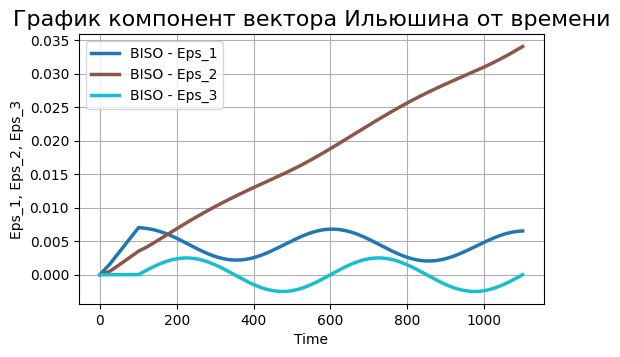

In [71]:
from core.calculations import calculate_ilushin_strain_vector


numerical_experiment_biso_strain_vector = calculate_ilushin_strain_vector(
    numerical_experiment_biso,
    compressible = abs(nu - 0.5) >= 1e-6
)

plot_xy([
        (model_name, numerical_experiment_biso_strain_vector)
    ],
    "Time",
    ["Eps_1", "Eps_2", "Eps_3"],
    f"График компонент вектора Ильюшина от времени"
)

### 4. Разделение этапов деформирования
Процесс нагружения состоит из двух этапов:
1.  **Одноосное растяжение** (прямолинейный участок траектории).
2.  **Сложное нагружение** (винтовая траектория).

Нам необходимо выделить данные, относящиеся только ко второму этапу, так как именно на нем исследуются эффекты сложного деформирования (кручение, кривизна траектории). Момент окончания первого этапа считываем из файла конфигурации `steps_n1.txt`.

In [72]:
step_n1_path = r"steps_n1.txt"
with open(step_n1_path, "r") as f:
        split_time = float(f.read().strip())
split_time

100.0

In [73]:
df_stage2 = numerical_experiment_biso_strain_vector[
    numerical_experiment_biso_strain_vector["Time"] > split_time
].copy()

df_stage2.reset_index(drop=True, inplace=True)
df_stage2["Time_Local"] = df_stage2["Time"] - split_time

In [74]:
df_stage2[:5]

,Time,Eps_1,Eps_2,Eps_3,Time_Local
0,100.0100,0.007028,0.003513,3.141510e-07,0.0100
1,100.0200,0.007028,0.003513,6.283020e-07,0.0200
2,100.0350,0.007028,0.003513,1.099528e-06,0.0350
3,100.0575,0.007028,0.003514,1.806368e-06,0.0575
4,100.0913,0.007028,0.003515,2.866628e-06,0.0913


In [75]:
filename = 'df_stage2_biso.pkl'
df_stage2.to_pickle(filename)

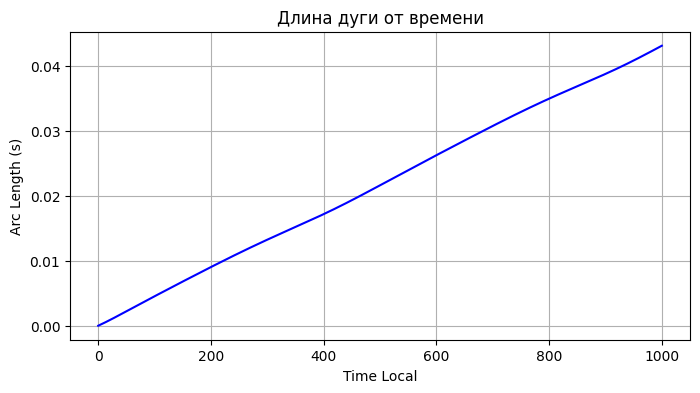

In [76]:
import numpy as np
import matplotlib.pyplot as plt

d_eps = df_stage2[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)
step_length = np.sqrt(d_eps['Eps_1']**2 + d_eps['Eps_2']**2 + d_eps['Eps_3']**2)
df_stage2['s'] = step_length.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(df_stage2['Time_Local'], df_stage2['s'], 'b-')
plt.xlabel('Time Local')
plt.ylabel('Arc Length (s)')
plt.title('Длина дуги от времени')
plt.grid(True)
plt.show()

### 5. Аналитическое решение

Для сравнения используется аналитическое решение для **идеально несжимаемого материала** ($\nu=0.5$). В этом случае траектория в пространстве деформаций является идеальной винтовой линией.

Параметризация выполняется по **длине дуги** $s$.
Связь угла поворота $\alpha$ и пути $s$ задается через пространственную частоту $\lambda$:
$$ \alpha(s) = \lambda \cdot s, \quad \text{где } \lambda = \frac{2\pi}{\sqrt{a^2 + (2\pi c)^2}} $$

Производные вычисляются по параметру $s$: $\frac{d\bar{\ni}}{ds}, \frac{d^2\bar{\ni}}{ds^2}, \frac{d^3\bar{\ni}}{ds^3}$.

---

**1. Уравнения траектории (зависимость от $\alpha$):**
В предположении несжимаемости ($\varepsilon_{mean}=0$) компоненты деформаций описываются кинематическими соотношениями:
$$ \varepsilon_z(\alpha) = c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_\theta(\alpha) = \frac{\sqrt{3} a \alpha}{4\pi} - \frac{1}{2} c \cdot (\cos\alpha - 1) $$
$$ \varepsilon_{\theta z}(\alpha) = \frac{\sqrt{3}}{2} c \cdot \sin\alpha $$

**2. Вектор Ильюшина (переход к базису $\ni_i$):**
Подставляя уравнения траектории в формулы преобразования к векторному пространству для несжимаемого материала:

$$ \ni_1(\alpha) = \varepsilon_z = c(\cos\alpha - 1) $$
$$ \ni_2(\alpha) = \frac{1}{\sqrt{3}}(\varepsilon_z + 2\varepsilon_\theta) = \frac{a \alpha}{2\pi} $$
$$ \ni_3(\alpha) = \frac{2}{\sqrt{3}}\varepsilon_{\theta z} = c \sin\alpha $$

**3. Производные по длине дуги $s$:**
Используя цепное правило дифференцирования $\frac{d}{ds} = \frac{d}{d\alpha} \frac{d\alpha}{ds} = \lambda \frac{d}{d\alpha}$, получаем:

*   **Первая производная (Скорость, $\mathbf{v}$):**
    $$ \ni_1' = -c \lambda \sin(\lambda s) $$
    $$ \ni_2' = \frac{a \lambda}{2\pi} = \text{const} $$
    $$ \ni_3' = c \lambda \cos(\lambda s) $$

*   **Вторая производная (Кривизна/Ускорение, $\mathbf{a}$):**
    $$ \ni_1'' = -c \lambda^2 \cos(\lambda s) $$
    $$ \ni_2'' = 0 $$
    $$ \ni_3'' = -c \lambda^2 \sin(\lambda s) $$

*   **Третья производная (Рывок, $\mathbf{j}$):**
    $$ \ni_1''' = c \lambda^3 \sin(\lambda s) $$
    $$ \ni_2''' = 0 $$
    $$ \ni_3''' = -c \lambda^3 \cos(\lambda s) $$

Эти формулы используются для аналитического расчета кривизны $\varkappa$ и кручения $\tau$. Из равенства нулю второй и третьей производной для компоненты $\ni_2$ следует, что для идеальной траектории геометрические характеристики должны быть **константами**.

In [77]:
step_n2_path = r"steps_n2.txt"
with open(step_n2_path, "r") as f:
        steps_n2 = float(f.read().strip())
steps_n2

1000.0

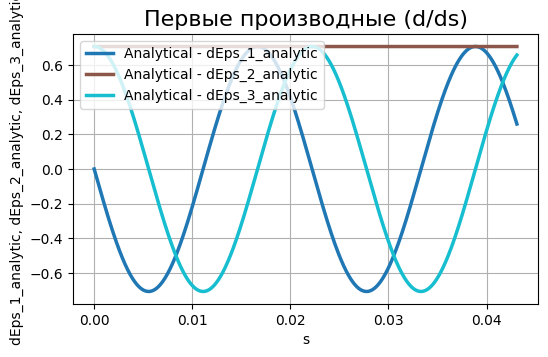

In [78]:
from core.derivatives.analytical import AnalyticalDerivatives

analytical = AnalyticalDerivatives(c=c, a=a) 

s_vals = df_stage2["s"].values

start_row = numerical_experiment_biso[numerical_experiment_biso["Time"] <= split_time].iloc[-1]
eps_z_start = start_row["EPTO_ZZ"]
eps_theta_start = start_row["EPTO_TT"]

E1, E2, E3 = analytical.get_values(s_vals, eps_z_start, eps_theta_start)
df_stage2["Eps_1_analytic"] = E1
df_stage2["Eps_2_analytic"] = E2
df_stage2["Eps_3_analytic"] = E3

dE, d2E, d3E = analytical.get_all_derivatives(s_vals)

df_stage2["dEps_1_analytic"] = dE[0]
df_stage2["dEps_2_analytic"] = dE[1]
df_stage2["dEps_3_analytic"] = dE[2]

df_stage2["d2Eps_1_analytic"] = d2E[0]
df_stage2["d2Eps_2_analytic"] = d2E[1]
df_stage2["d2Eps_3_analytic"] = d2E[2]

df_stage2["d3Eps_1_analytic"] = d3E[0]
df_stage2["d3Eps_2_analytic"] = d3E[1]
df_stage2["d3Eps_3_analytic"] = d3E[2]

plot_xy([("Analytical", df_stage2)], "s", ["dEps_1_analytic", "dEps_2_analytic", "dEps_3_analytic"], "Первые производные (d/ds)")

In [79]:
best_s, best_k = 2.7185882427329403e-12, 5

На основе проведенного анализа (Grid Search) были определены оптимальные значения гиперпараметров сплайна ($s_{opt}, k_{opt}$), обеспечивающие наилучший баланс между точностью аппроксимации и гладкостью высших производных.

Так как погрешности решателя ANSYS одинаковы для всех компонент деформаций, мы применяем найденные параметры для дифференцирования **всех компонент** вектора Ильюшина ($\ni_1, \ni_2, \ni_3$).

В результате для каждой компоненты вычисляются и сохраняются в DataFrame:
1.  **Скорость** ($\dot{\ni}$) — префикс `d`
2.  **Ускорение** ($\ddot{\ni}$) — префикс `d2`
3.  **Рывок** ($\dddot{\ni}$) — префикс `d3` (необходим для расчета кручения $\tau$)

In [80]:
from core.derivatives.spline import compute_spline_derivatives


components = ["Eps_1", "Eps_2", "Eps_3"]
for col in components:
    d1, d2, d3 = compute_spline_derivatives(
        df_stage2, 
        col_name=col, 
        time_col="s", 
        s=best_s, 
        k=best_k
    )

    # Названия колонок: dEps_1_spline, d2Eps_1_spline, d3Eps_1_spline
    df_stage2[f"d{col}_spline"] = d1
    df_stage2[f"d2{col}_spline"] = d2
    df_stage2[f"d3{col}_spline"] = d3

Ниже представлены графики изменения компонент вектора деформаций $\ni_1$ и $\ni_3$, а также их вычисленных производных: скорости ($\dot{\ni}$), ускорения ($\ddot{\ni}$) и рывка ($\dddot{\ni}$).

*   **Компонента $\ni_1$** (соответствует осевой деформации $\varepsilon_z$) — отражает процесс растяжения/сжатия в ходе движения по винтовой траектории.
*   **Компонента $\ni_3$** (соответствует сдвигу $\varepsilon_{\theta z}$) — отражает процесс чистого кручения.

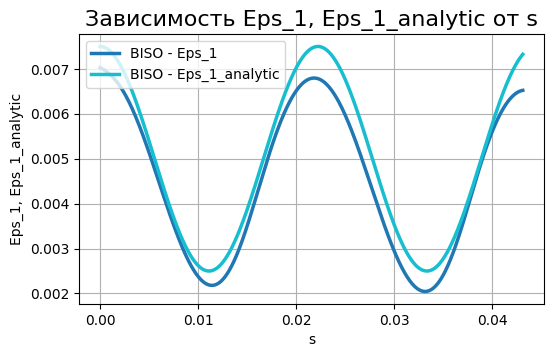

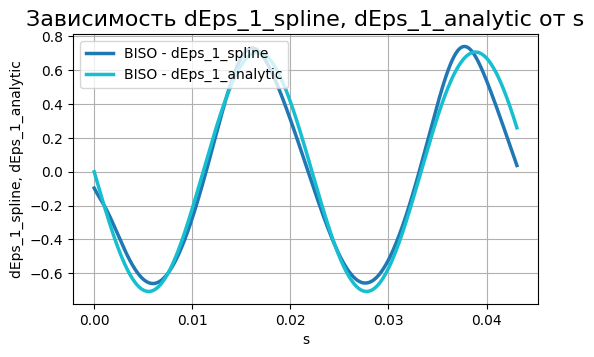

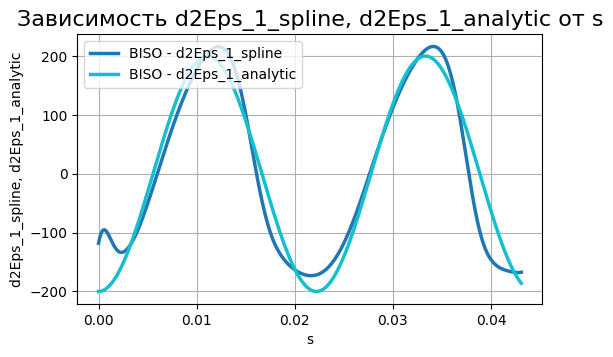

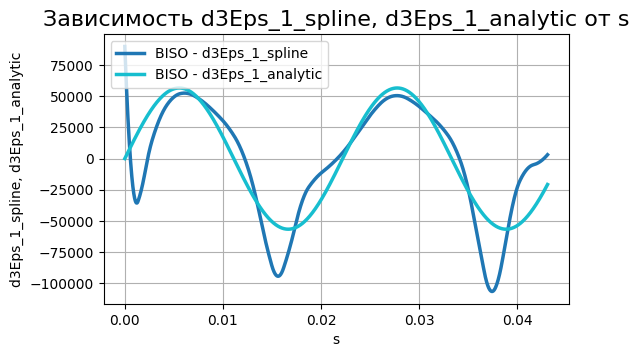

In [81]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_1", "Eps_1_analytic"],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_1_spline", "dEps_1_analytic"],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_1_spline", "d2Eps_1_analytic"],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d3Eps_1_spline", "d3Eps_1_analytic"],
)

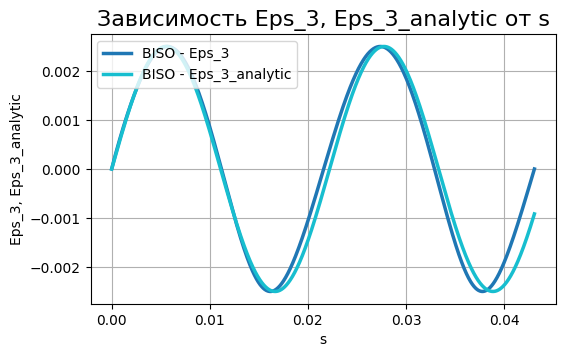

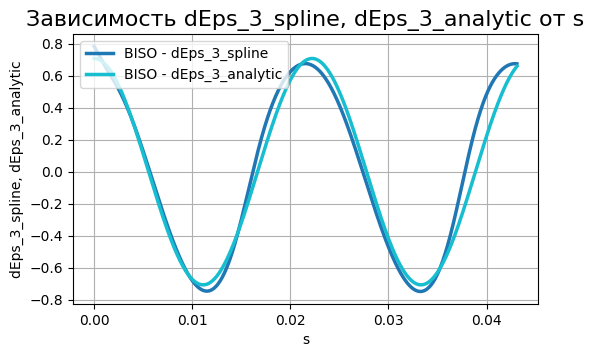

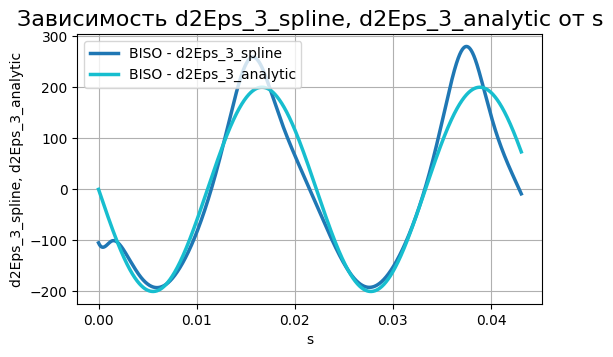

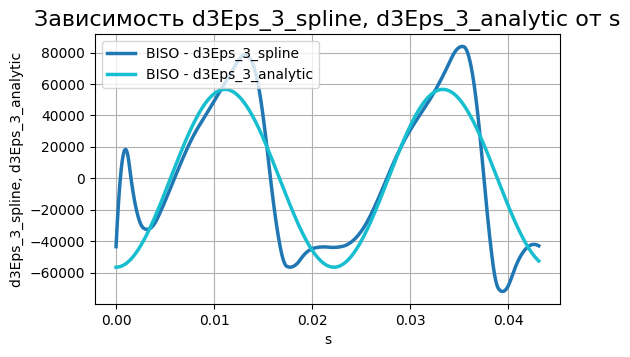

In [82]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["Eps_3",
            "Eps_3_analytic",
        ],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["dEps_3_spline",
            "dEps_3_analytic",
        ],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d2Eps_3_spline",
            "d2Eps_3_analytic",
        ],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["d3Eps_3_spline",
            "d3Eps_3_analytic"
        ],
)

### 6. Расчет геометрических характеристик траектории

Используя вычисленные производные (скорость $\dot{\bar{\ni}}$, ускорение $\ddot{\bar{\ni}}$, рывок $\dddot{\bar{\ni}}$), мы определяем внутреннюю геометрию траектории деформирования в векторном пространстве.

**Вычисляемые параметры:**

1.  **Длина дуги траектории деформаций $s$:**
    Натуральный параметр процесса, характеризующий накопленную деформацию.
    $$ s(t) = \int_0^t |\dot{\bar{\ni}}(\tau)| d\tau $$

2.  **Кривизна $\varkappa$ (Curvature):**
    Характеризует отклонение траектории от прямой линии.
    $$ \varkappa = \frac{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|}{|\dot{\bar{\ni}}|^3} $$

3.  **Кручение $\tau$ (Torsion):**
    Характеризует выход траектории из плоскости соприкасания (отклонение от плоской кривой).
    $$ \tau = \frac{(\dot{\bar{\ni}} \times \ddot{\bar{\ni}}) \cdot \dddot{\bar{\ni}}}{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|^2} $$

Расчет производится параллельно для двух наборов данных:
*   **Analytic:** На основе точных формул (эталон).
*   **Spline:** На основе численного дифференцирования данных ANSYS (проверка методики).

In [83]:
import numpy as np
from core.calculations import calculate_geometry

s_true, k_true, t_true = calculate_geometry(df_stage2, suffix="_analytic", time_col="s")

df_stage2["s_analytic"] = s_true
df_stage2["kappa_analytic"] = k_true
df_stage2["tau_analytic"] = np.round(np.abs(t_true), decimals=7)

s_spline, k_spline, t_spline = calculate_geometry(df_stage2, suffix="_spline", time_col="s")

df_stage2["s_spline"] = s_spline
df_stage2["kappa_spline"] = k_spline
df_stage2["tau_spline"] = np.abs(t_spline)

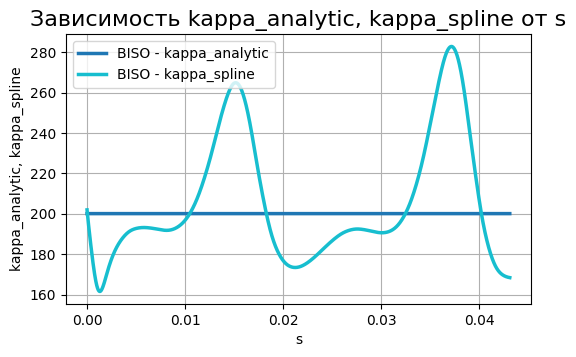

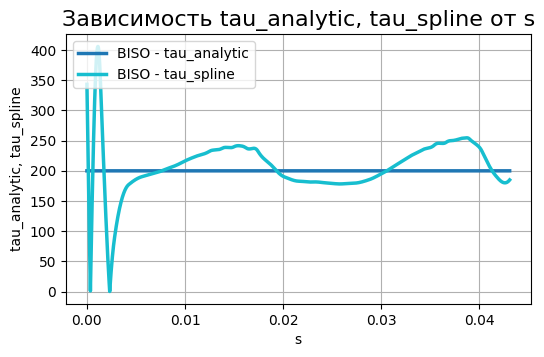

In [84]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["kappa_analytic", "kappa_spline"],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="s",
    y_cols=["tau_analytic", "tau_spline"],
)

In [85]:
from core.derivatives.stress_approximation import VolumetricModel

cols_stress = ['S_ZZ', 'S_TT']
df_stress = numerical_experiment_biso.loc[numerical_experiment_biso['Time'] > split_time, cols_stress].reset_index(drop=True)
df_stage2 = pd.concat([df_stage2, df_stress], axis=1)
df_stage2['Sigma_Mean'] = (df_stage2['S_ZZ'] + df_stage2['S_TT']) / 3.0

vol_model = VolumetricModel()
vol_model.fit(df_stage2['s'].values, df_stage2['Sigma_Mean'].values)

array([1.20399160e+02, 2.89054677e+02, 6.71777767e-01, 4.29344126e+03,
       1.94746821e+02])

Параметры аппроксимации среднего напряжения:
  Амплитуда (p):       120.3992 МПа
  Пространств. частота (w): 289.0547 рад/мм
  Линейный тренд (b1): 4293.4413 МПа/мм
  Базовое смещение (b2): 194.7468 МПа


<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Arina\AppData\Local\Temp\ipykernel_17256\1554018736.py:27: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$', fontsize=14)


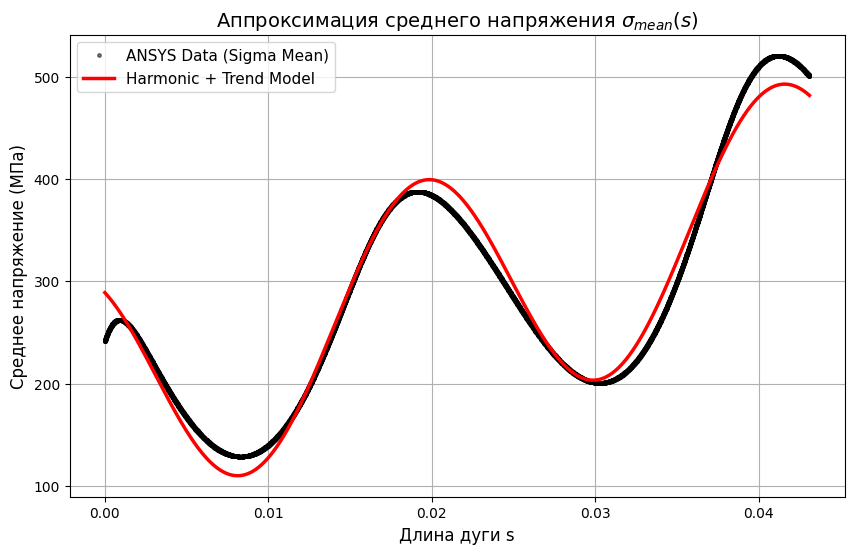

In [86]:
import matplotlib.pyplot as plt

# 1. Получаем данные
s_vals = df_stage2['s'].values
sigma_real = df_stage2['Sigma_Mean'].values
sigma_approx = vol_model.predict(s_vals)

# 2. Вывод найденных коэффициентов (для анализа)
# Порядок параметров в VolumetricModel: [p, w, phi, b1, b2]
p, w, phi, b1, b2 = vol_model.params

print(f"Параметры аппроксимации среднего напряжения:")
print(f"  Амплитуда (p):       {p:.4f} МПа")
print(f"  Пространств. частота (w): {w:.4f} рад/мм")
print(f"  Линейный тренд (b1): {b1:.4f} МПа/мм")
print(f"  Базовое смещение (b2): {b2:.4f} МПа")

# 3. Построение графика
plt.figure(figsize=(10, 6))

# Исходные данные из ANSYS (черные точки)
plt.plot(s_vals, sigma_real, 'k.', markersize=5, alpha=0.5, label='ANSYS Data (Sigma Mean)')

# Аппроксимация (красная линия)
plt.plot(s_vals, sigma_approx, 'r-', linewidth=2.5, label='Harmonic + Trend Model')

plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$', fontsize=14)
plt.xlabel('Длина дуги s', fontsize=12)
plt.ylabel('Среднее напряжение (МПа)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

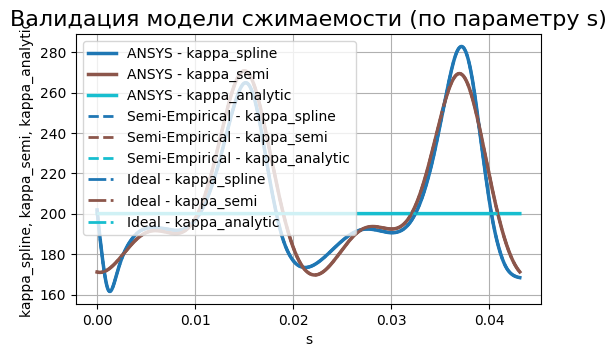

In [87]:
from core.derivatives.stress_approximation import SemiEmpiricalGeometry


semi_emp = SemiEmpiricalGeometry(vol_model, E=2.05e5, nu=nu, c=c, a=a)
k_semi, t_semi = semi_emp.compute_geometry(df_stage2['s'].values)

df_stage2['kappa_semi'] = k_semi
df_stage2['tau_semi'] = np.abs(t_semi)

# 4. Финальный график
plot_xy(
    [('ANSYS', df_stage2), ('Semi-Empirical', df_stage2), ('Ideal', df_stage2)],
    "s", 
    ["kappa_spline", "kappa_semi", "kappa_analytic"],
    "Валидация модели сжимаемости (по параметру s)"
)

### 7. Векторные свойства материала: Расчет угла сближения

Для анализа векторных свойств материала (отклонения поведения от теории малых упруго-пластических деформаций) необходимо сопоставить направление вектора напряжений $\bar{\sigma}$ с направлением мгновенной скорости деформации $\dot{\bar{\ni}}$ (касательной к траектории).

**1. Построение вектора напряжений $\bar{\sigma}$**
Вектор напряжений в пространстве Ильюшина строится на основе компонент **девиатора напряжений** $S_{ij}$. Результаты ANSYS (для элемента PLANE182) содержат компоненты тензора напряжений: $\sigma_z$ (осевое), $\sigma_\theta$ (окружное) и $\tau_{z\theta}$ (касательное).

Сначала вычисляются компоненты девиатора:
$$ S_{zz} = \sigma_z - \sigma_{mean}, \quad S_{\theta\theta} = \sigma_\theta - \sigma_{mean}, \quad S_{z\theta} = \tau_{z\theta} $$
где $\sigma_{mean} = \frac{1}{3}(\sigma_z + \sigma_\theta)$.

Компоненты вектора $\bar{\sigma}$ определяются линейным преобразованием:
$$ \sigma_1 = \frac{3}{2} S_{zz} $$
$$ \sigma_2 = \frac{\sqrt{3}}{2} (S_{zz} + 2S_{\theta\theta}) $$
$$ \sigma_3 = \sqrt{3} S_{z\theta} $$

**2. Расчет угла сближения $\vartheta_1$**
Угол сближения (или угол запаздывания) $\vartheta_1$ — это угол между вектором напряжений $\bar{\sigma}$ и вектором скорости деформаций $\dot{\bar{\ni}}$ в пятимерном пространстве. Он вычисляется через скалярное произведение:

$$ \cos \vartheta_1 = \frac{\bar{\sigma} \cdot \dot{\bar{\ni}}}{|\bar{\sigma}| \cdot |\dot{\bar{\ni}}|} $$

Этот параметр характеризует степень неколлинеарности тензоров напряжений и скоростей деформаций, возникающую вследствие сложного нагружения.

In [88]:
df_stress_stage2 = numerical_experiment_biso.loc[
    numerical_experiment_biso["Time"] > split_time, 
    ["S_ZZ", "S_TZ", "S_TT", "Time"]
].copy()

df_stress_stage2.reset_index(drop=True, inplace=True)

df_stress_stage2["Time_Local"] = df_stress_stage2["Time"] - split_time

df_stress_stage2[:5]

,S_ZZ,S_TZ,S_TT,Time,Time_Local
0,489.3062,0.042900,236.5553,100.0100,0.0100
1,489.3083,0.085799,236.6123,100.0200,0.0200
2,489.3116,0.150142,236.6976,100.0350,0.0350
3,489.3164,0.246647,236.8256,100.0575,0.0575
4,489.3233,0.391381,237.0175,100.0913,0.0913


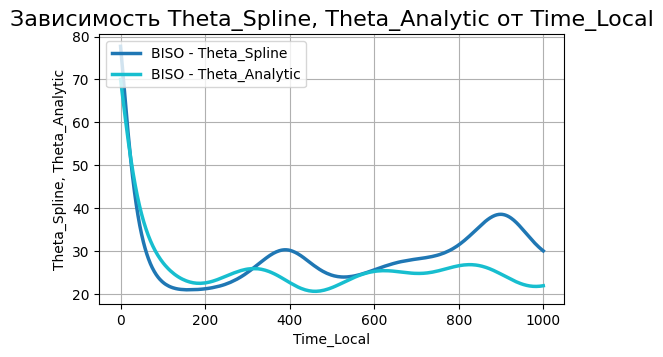

In [89]:
from core.calculations import calculate_stress_vector, calculate_theta


sig_1, sig_2, sig_3 = calculate_stress_vector(df_stress_stage2)
df_stage2["Sig_1"] = sig_1
df_stage2["Sig_2"] = sig_2
df_stage2["Sig_3"] = sig_3

theta_spline = calculate_theta(df_stage2, deriv_suffix="_spline")
df_stage2["Theta_Spline"] = theta_spline

theta_analytic = calculate_theta(df_stage2, deriv_suffix="_analytic")
df_stage2["Theta_Analytic"] = theta_analytic


plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="Time_Local",
    y_cols=["Theta_Spline", "Theta_Analytic"],
)

In [90]:
best_s_roughness, best_k_roughness = 2.7185882427329403e-12, 4

In [91]:
from core.derivatives.spline import compute_spline_derivatives


components = ["Eps_1", "Eps_2", "Eps_3"]
for col in components:
    d1, d2, d3 = compute_spline_derivatives(
        df_stage2, 
        col_name=col, 
        time_col="Time_Local", 
        s=best_s_roughness, 
        k=best_k_roughness
    )

    df_stage2[f"d{col}_spline_roughness"] = d1
    df_stage2[f"d2{col}_spline_roughness"] = d2
    df_stage2[f"d3{col}_spline_roughness"] = d3

In [92]:
s_spline, k_spline, t_spline = calculate_geometry(df_stage2, suffix="_spline_roughness")

df_stage2["s_spline_roughness"] = s_spline
df_stage2["kappa_spline_roughness"] = k_spline
df_stage2["tau_spline_roughness"] = np.abs(t_spline)

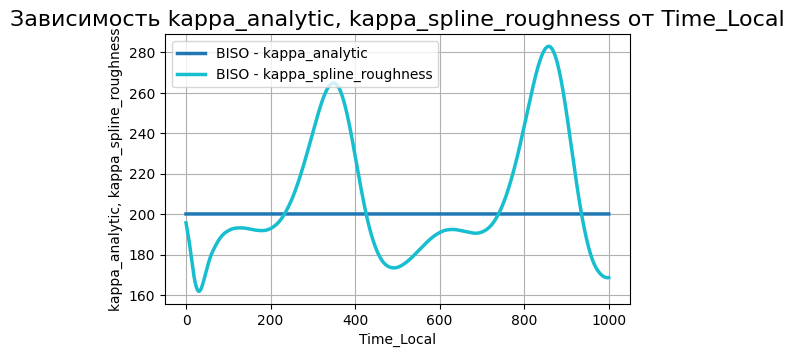

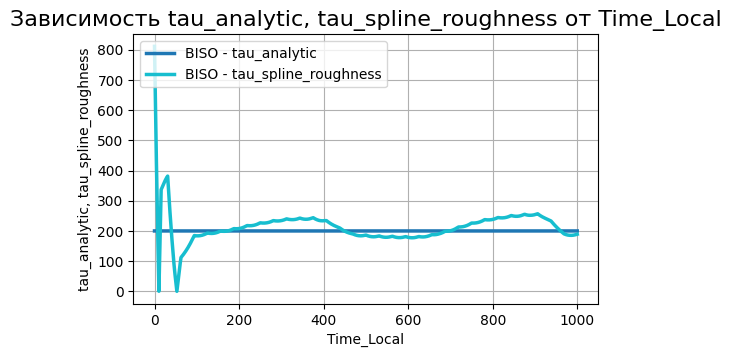

In [93]:
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="Time_Local",
    y_cols=["kappa_analytic", "kappa_spline_roughness"],
)
plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="Time_Local",
    y_cols=["tau_analytic", "tau_spline_roughness"],
)

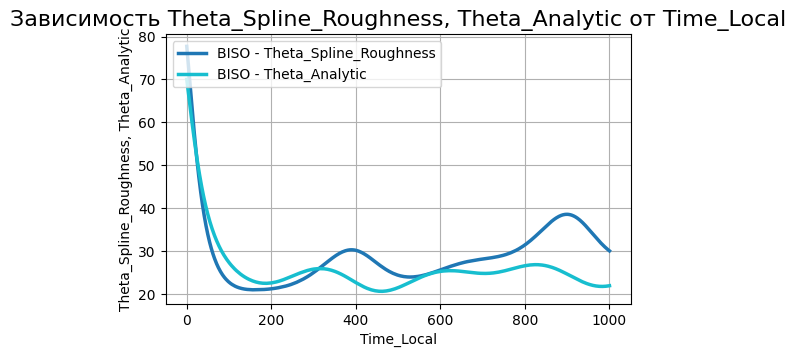

In [94]:
theta_spline_roughness = calculate_theta(df_stage2, deriv_suffix="_spline_roughness")
df_stage2["Theta_Spline_Roughness"] = theta_spline

plot_xy(
    data_pairs=[(model_name, df_stage2)],
    x_col="Time_Local",
    y_cols=["Theta_Spline_Roughness", "Theta_Analytic"],
)

In [95]:
import pandas as pd

cols_to_add = ['S_ZZ', 'S_TT']

df_stress_part = numerical_experiment_biso.loc[
    numerical_experiment_biso['Time'] > split_time, 
    cols_to_add
].copy().reset_index(drop=True)

df_stage2 = pd.concat([df_stage2, df_stress_part], axis=1)
df_stage2['Sigma_Mean'] = (df_stage2['S_ZZ'] + df_stage2['S_TT']) / 3.0

display(df_stage2[['Time_Local', 'S_ZZ', 'S_TT', 'Sigma_Mean']].head())

ValueError: Columns must be same length as key

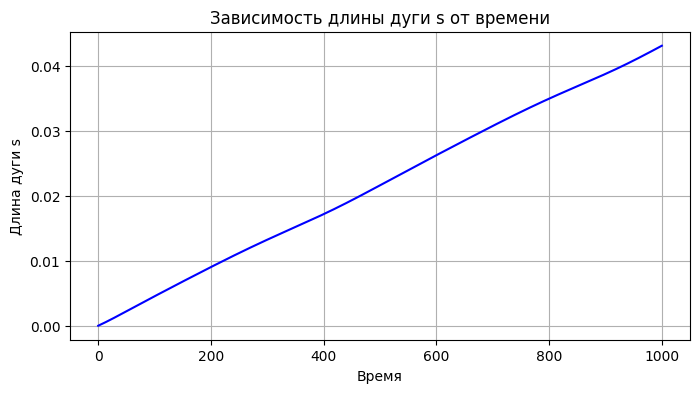

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d_eps = df_stage2[['Eps_1', 'Eps_2', 'Eps_3']].diff().fillna(0)
step_length = np.sqrt(d_eps['Eps_1']**2 + d_eps['Eps_2']**2 + d_eps['Eps_3']**2)
df_stage2['s'] = step_length.cumsum()
plt.figure(figsize=(8, 4))
plt.plot(df_stage2['Time_Local'], df_stage2['s'], 'b-')
plt.title('Зависимость длины дуги s от времени')
plt.xlabel('Время')
plt.ylabel('Длина дуги s')
plt.grid(True)
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Arina\AppData\Local\Temp\ipykernel_17256\1254826437.py:42: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$')


Параметры аппроксимации Sigma_Mean(s):
  Амплитуда (p): 120.3992 МПа
  Частота (w):   289.0547 рад/ед.деф.
  Тренд (b1):    4293.4413 МПа/ед.деф.
  Сдвиг (b2):    194.7468 МПа


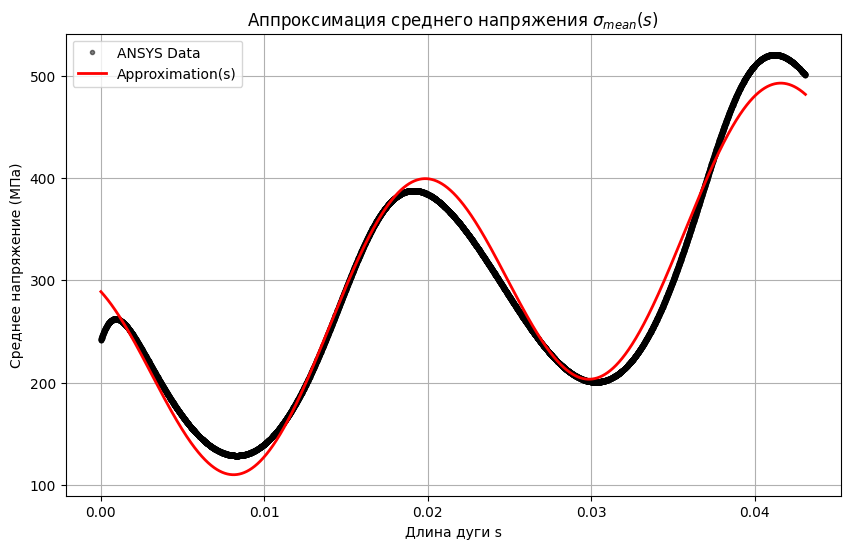

In [ ]:
from scipy.optimize import curve_fit

# 1. Данные для фиттинга
x_data = df_stage2['s'].values
y_data = df_stage2['Sigma_Mean'].values

# 2. Модель (гармоника + линейный тренд)
def harmonic_trend_model(s, p, w, phi, b1, b2):
    return p * np.cos(w * s + phi) + b1 * s + b2

# 3. Подбор начальных параметров (Guess)
# w: Мы знаем, что это винтовая линия. Полный оборот происходит за длину s_turn.
# Длина витка L ~ sqrt((2*pi*c)^2 + a^2). У нас 2 витка.
# w ~ 2*pi / (L_total / 2)
# Но проще доверить это curve_fit или оценить через FFT, как делали раньше.
# Попробуем грубую оценку: w ~ 2 полных колебания на всю длину s
w_guess = (2 * 2 * np.pi) / x_data[-1]

# Линейный тренд
b1_guess = (y_data[-1] - y_data[0]) / (x_data[-1] - x_data[0])
b2_guess = np.mean(y_data)
p_guess = (y_data.max() - y_data.min()) / 2

p0 = [p_guess, w_guess, 0.0, b1_guess, b2_guess]

# 4. Оптимизация
try:
    popt_s, pcov_s = curve_fit(harmonic_trend_model, x_data, y_data, p0=p0)
    
    p_s, w_s, phi_s, b1_s, b2_s = popt_s
    
    print("Параметры аппроксимации Sigma_Mean(s):")
    print(f"  Амплитуда (p): {p_s:.4f} МПа")
    print(f"  Частота (w):   {w_s:.4f} рад/ед.деф.")
    print(f"  Тренд (b1):    {b1_s:.4f} МПа/ед.деф.")
    print(f"  Сдвиг (b2):    {b2_s:.4f} МПа")

    # 5. Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data, 'k.', label='ANSYS Data', alpha=0.5)
    plt.plot(x_data, harmonic_trend_model(x_data, *popt_s), 'r-', lw=2, label='Approximation(s)')
    plt.title('Аппроксимация среднего напряжения $\sigma_{mean}(s)$')
    plt.xlabel('Длина дуги s')
    plt.ylabel('Среднее напряжение (МПа)')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"Не удалось подобрать параметры: {e}")

<>:119: SyntaxWarning: invalid escape sequence '\k'
<>:119: SyntaxWarning: invalid escape sequence '\k'
C:\Users\Arina\AppData\Local\Temp\ipykernel_17256\667135340.py:119: SyntaxWarning: invalid escape sequence '\k'
  plt.title('Кривизна $\kappa(s)$: Проверка гипотезы через среднее напряжение')


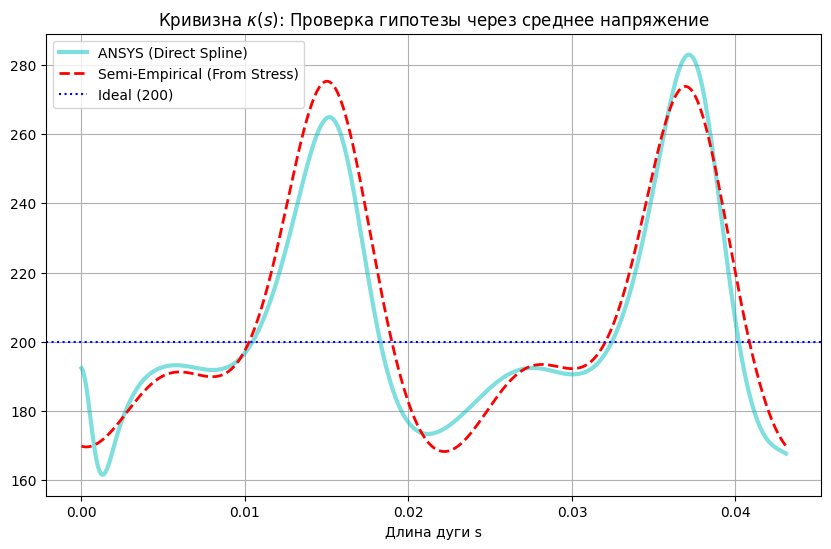

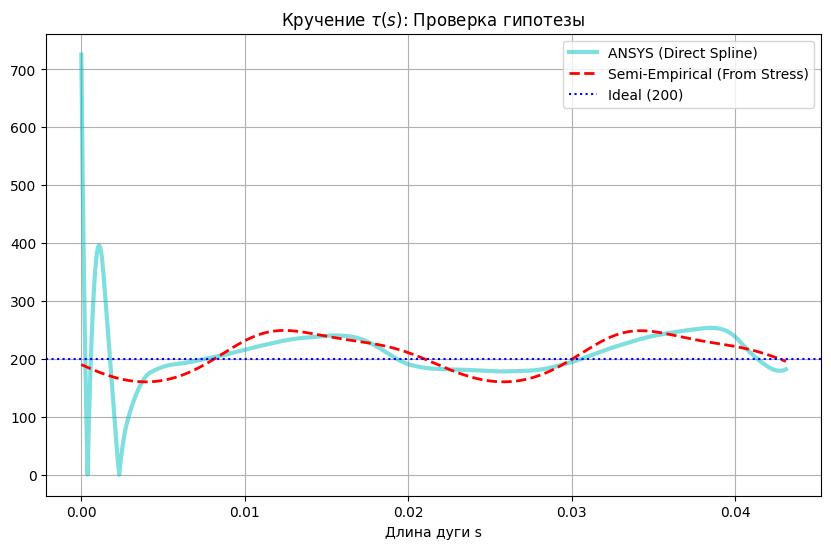

In [ ]:
def calculate_curvature_torsion_from_stress_fit(s_array, stress_params, E=2.05e5, nu=0.29, c=25e-4, a=157e-4):
    """
    Вычисляет кривизну и кручение, используя аппроксимацию СРЕДНЕГО НАПРЯЖЕНИЯ.
    """
    # 1. Параметры аппроксимации напряжения: sigma_mean(s)
    # sig = p*cos(w*s + phi) + b1*s + b2
    p_sig, w_fit, phi, b1_sig, b2_sig = stress_params
    
    # 2. Коэффициент перевода Напряжение -> Деформация (Закон Гука для объема)
    # eps_mean = sigma_mean * (1 - 2*nu) / E
    k_mat = (1 - 2*nu) / E
    
    # Параметры для деформации delta(s)
    p = p_sig * k_mat
    b1 = b1_sig * k_mat
    # w и phi остаются теми же (фаза и частота не меняются)
    w = w_fit 
    
    # 3. Параметры Идеальной кинематики (Винт)
    # Нам нужно связать угол alpha с длиной дуги s.
    # Для идеального винта: s = alpha * R_eff
    # R_eff = sqrt( (a/2pi)^2 + c^2 ) ... или проще через длину витка
    # Длина одного витка L = sqrt(a^2 + (2*pi*c)^2)
    # Угол полного витка = 2*pi
    # Коэффициент lambda = alpha / s = 2*pi / L
    
    L_turn = np.sqrt(a**2 + (2 * np.pi * c)**2)
    lam = (2 * np.pi) / L_turn
    
    # Аргумент для кинематики
    arg_kin = lam * s_array
    
    # Аргумент для эмпирической части (delta)
    arg_emp = w * s_array + phi
    
    # --- ПРОИЗВОДНЫЕ ПО s (d/ds) ---
    sqrt3 = np.sqrt(3)
    
    # A. Производные DELTA (объема)
    # d = p*cos(...) + b1*s
    d1_delta = -p * w * np.sin(arg_emp) + b1
    d2_delta = -p * w**2 * np.cos(arg_emp)
    d3_delta =  p * w**3 * np.sin(arg_emp)
    
    # B. Производные КИНЕМАТИКИ (Идеальной)
    # eps_z = c * (cos(lam*s) - 1)
    # d_ez = -c * lam * sin
    d1_ez = -c * lam * np.sin(arg_kin)
    d2_ez = -c * lam**2 * np.cos(arg_kin)
    d3_ez =  c * lam**3 * np.sin(arg_kin)
    
    # eps_theta_z = (sqrt3/2)*c * sin(lam*s)
    d1_etz = (sqrt3/2) * c * lam * np.cos(arg_kin)
    d2_etz = -(sqrt3/2) * c * lam**2 * np.sin(arg_kin)
    d3_etz = -(sqrt3/2) * c * lam**3 * np.cos(arg_kin)
    
    # eps_theta (линейная часть + синус)
    # Линейный вклад в Ni_2 дает константу в скорости и 0 в ускорении.
    # Ni_2_ideal = (a * lam * s) / (2 * pi) ... грубо говоря линейный рост
    # d(Ni_2_ideal)/ds = Const
    # d2(Ni_2_ideal)/ds2 = 0
    # d3(...) = 0
    # Но мы должны быть точны. 
    # Ni_2 = 1/sqrt3 * (ez + 2*et)
    # В идеальном случае (несжимаемом) Ni_2 линейна по s.
    # Значит d1_ni2_ideal = const, d2 = 0, d3 = 0.
    # Константа скорости = a / L_turn (примерно). 
    # Точнее: d1_ni2_ideal = a / (2*pi) * lam = a / L_turn.
    
    d1_ni2_id = a / L_turn
    d2_ni2_id = 0.0
    d3_ni2_id = 0.0
    
    # --- C. СБОРКА ВЕКТОРА ИЛЬЮШИНА ---
    
    # Компонента 1: Ni_1 = eps_z - delta
    v1 = d1_ez - d1_delta
    a1 = d2_ez - d2_delta
    j1 = d3_ez - d3_delta
    
    # Компонента 2: Ni_2 = Ni_2_ideal - sqrt(3)*delta
    v2 = d1_ni2_id - sqrt3 * d1_delta
    a2 = d2_ni2_id - sqrt3 * d2_delta
    j2 = d3_ni2_id - sqrt3 * d3_delta
    
    # Компонента 3: Ni_3 = 2/sqrt3 * eps_theta_z (не зависит от delta)
    v3 = (2/sqrt3) * d1_etz
    a3 = (2/sqrt3) * d2_etz
    j3 = (2/sqrt3) * d3_etz
    
    # Упаковка
    V = np.column_stack((v1, v2, v3))
    A = np.column_stack((a1, a2, a3))
    J = np.column_stack((j1, j2, j3))
    
    # --- D. РАСЧЕТ ГЕОМЕТРИИ ---
    # 1. Кривизна k = |V x A| / |V|^3
    cross_va = np.cross(V, A)
    num_k = np.linalg.norm(cross_va, axis=1)
    den_k = np.linalg.norm(V, axis=1)**3
    kappa = num_k / den_k
    
    # 2. Кручение tau = ((V x A) . J) / |V x A|^2
    num_t = np.sum(cross_va * J, axis=1)
    den_t = np.linalg.norm(cross_va, axis=1)**2
    tau = num_t / den_t
    
    return kappa, tau

# === ЗАПУСК ===
# Используем popt_s (параметры аппроксимации среднего напряжения), которые нашли ранее
k_semi, t_semi = calculate_curvature_torsion_from_stress_fit(x_data, popt_s)

# Визуализация Кривизны
plt.figure(figsize=(10, 6))
plt.plot(x_data, df_stage2['kappa_spline'], 'c-', alpha=0.5, lw=3, label='ANSYS (Direct Spline)')
plt.plot(x_data, k_semi, 'r--', lw=2, label='Semi-Empirical (From Stress)')
plt.axhline(200, color='b', linestyle=':', label='Ideal (200)')
plt.title('Кривизна $\kappa(s)$: Проверка гипотезы через среднее напряжение')
plt.xlabel('Длина дуги s')
plt.legend(); plt.grid(True); plt.show()

# Визуализация Кручения
plt.figure(figsize=(10, 6))
plt.plot(x_data, np.abs(df_stage2['tau_spline']), 'c-', alpha=0.5, lw=3, label='ANSYS (Direct Spline)')
plt.plot(x_data, np.abs(t_semi), 'r--', lw=2, label='Semi-Empirical (From Stress)')
plt.axhline(200, color='b', linestyle=':', label='Ideal (200)')
plt.title('Кручение $\\tau(s)$: Проверка гипотезы')
plt.xlabel('Длина дуги s')
plt.legend(); plt.grid(True); plt.show()